In [1]:
import pandas as pd
import numpy as np

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
train_raw = pd.read_csv('AP1_normal_train.csv')
test_raw  = pd.read_csv('AP1_normal_test.csv')

print(train_raw.shape, test_raw.shape)

(23645, 10) (5912, 10)


In [3]:
station_pair_counts = train_raw.groupby(['startStation', 'endStation']).size().reset_index(name='count')
valid_pairs = station_pair_counts[station_pair_counts['count'] >= 10][['startStation', 'endStation']]

train_raw = train_raw.merge(valid_pairs, on=['startStation', 'endStation'], how='inner')
test_raw = test_raw.merge(valid_pairs, on=['startStation', 'endStation'], how='inner')

print(f"After filtering: train shape {train_raw.shape}, test shape {test_raw.shape}")

After filtering: train shape (23565, 10), test shape (5890, 10)


In [4]:
def add_lag_features(df):
    df = df.copy()

    lag_cols = ['weather', 'trafficCondition', 'passengerFlow']

    for col in lag_cols:
        df[f'{col}_lag1'] = df[col].shift(1)
        df[f'{col}_lag2'] = df[col].shift(2)
        df[f'{col}_roll3_mean'] = df[col].rolling(3).mean()

    df['arrivalDuration_lag1'] = df['arrivalDuration'].shift(1)
    df['arrivalDuration_roll3_mean'] = df['arrivalDuration'].rolling(3).mean()

    df.bfill(inplace=True)
    return df

train_df = add_lag_features(train_raw)
test_df  = add_lag_features(test_raw)

In [5]:
pair_te = (
    train_df
    .groupby(['startStation', 'endStation'])['arrivalDuration']
    .mean()
    .reset_index()
    .rename(columns={'arrivalDuration': 'pair_te_mean'})
)

train_df = train_df.merge(pair_te, on=['startStation', 'endStation'], how='left')
test_df  = test_df.merge(pair_te,  on=['startStation', 'endStation'], how='left')

global_mean = train_df['arrivalDuration'].mean()
train_df['pair_te_mean'] = train_df['pair_te_mean'].fillna(global_mean)
test_df['pair_te_mean']  = test_df['pair_te_mean'].fillna(global_mean)

In [6]:
SHORT_TH = 60

train_df['is_short'] = (train_df['arrivalDuration'] < SHORT_TH).astype(int)
test_df['is_short']  = (test_df['arrivalDuration'] < SHORT_TH).astype(int)

train_short = train_df[train_df['is_short'] == 1]
train_long  = train_df[train_df['is_short'] == 0]

test_short  = test_df[test_df['is_short'] == 1]
test_long   = test_df[test_df['is_short'] == 0]

print(len(train_short), len(train_long))

8184 15381


In [7]:
drop_cols = ['arrivalDuration', 'time', 'time_sec', 'busPlate']

def prepare_xy(df):
    X = df.drop(columns=drop_cols, errors='ignore')
    y_log = np.log1p(df['arrivalDuration'])
    return X, y_log

Xs_tr, ys_tr = prepare_xy(train_short)
Xl_tr, yl_tr = prepare_xy(train_long)

Xs_te, ys_te_raw = prepare_xy(test_short)
Xl_te, yl_te_raw = prepare_xy(test_long)

In [8]:
knn_params = dict(
    n_neighbors=5,
    weights='distance',
    n_jobs=-1
)

model_short = KNeighborsRegressor(**knn_params)
model_long  = KNeighborsRegressor(**knn_params)

model_short.fit(Xs_tr, ys_tr)
model_long.fit(Xl_tr, yl_tr)

KNeighborsRegressor(n_jobs=-1, weights='distance')

In [9]:
pred_short = np.expm1(model_short.predict(Xs_te))
pred_long  = np.expm1(model_long.predict(Xl_te))

test_df['predictedArrivalDuration'] = np.nan
test_df.loc[test_short.index, 'predictedArrivalDuration'] = pred_short
test_df.loc[test_long.index,  'predictedArrivalDuration'] = pred_long

In [10]:
y_true = test_df['arrivalDuration']
y_pred = test_df['predictedArrivalDuration']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mask = y_true >= 60
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("Final Dual-Model KNN Results")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

Final Dual-Model KNN Results
MAE  : 15.21
RMSE : 35.49
MAPE : 14.17%


In [11]:
eval_df = test_df.copy()
eval_df['error'] = eval_df['predictedArrivalDuration'] - eval_df['arrivalDuration']

adjacent_df = eval_df[(eval_df['endStation'] - eval_df['startStation']) == 1]

station_eval = (
    adjacent_df
    .groupby(['startStation', 'endStation'])
    .agg(
        Samples=('arrivalDuration', 'count'),
        MAE=('error', lambda x: np.mean(np.abs(x))),
        RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),
        MAPE=(
            'arrivalDuration',
            lambda x: np.mean(
                np.abs(
                    (x - adjacent_df.loc[x.index, 'predictedArrivalDuration'])
                    / np.maximum(x, 60)
                )
            ) * 100
        )
    )
    .reset_index()
)

station_eval

,startStation,endStation,Samples,MAE,RMSE,MAPE
0,0,1,250,37.249459,95.324217,25.358620
1,1,2,249,14.585097,22.274390,18.539340
2,2,3,258,21.066208,34.160879,22.214165
3,3,4,267,22.686931,37.602856,21.242396
4,4,5,274,14.136518,19.691075,10.097021
5,5,6,265,7.143188,9.526632,11.771797
6,6,7,247,18.375957,29.463132,3.459799
7,7,8,246,9.870266,14.847864,9.315160
8,8,9,262,10.120727,14.349627,14.406928
9,9,10,266,4.551925,6.135193,7.585454


In [12]:
# station_eval.to_csv('knn_normal-normal_remove.csv', index=False)
# print("Station-level evaluation saved")

test_df['mean_arrivalDuration'] = test_df['pair_te_mean']
test_df['error'] = test_df['predictedArrivalDuration'] - test_df['arrivalDuration']

In [13]:
external_file = "AP1_normal_train.csv"
external_df = pd.read_csv(external_file)

MIN_PAIR_SAMPLES = 5

ext_pair_counts = (
    external_df
    .groupby(['startStation', 'endStation'])
    .size()
    .reset_index(name='count')
)

ext_valid_pairs = ext_pair_counts[
    ext_pair_counts['count'] >= MIN_PAIR_SAMPLES
][['startStation', 'endStation']]

external_df_filtered = external_df.merge(
    ext_valid_pairs,
    on=['startStation', 'endStation'],
    how='inner'
)

external_pair_mean = (
    external_df_filtered
    .groupby(['startStation', 'endStation'])['arrivalDuration']
    .mean()
    .reset_index()
    .rename(columns={'arrivalDuration': 'external_pair_mean'})
)

test_df = test_df.merge(
    external_pair_mean,
    on=['startStation', 'endStation'],
    how='left'
)

global_mean = external_df['arrivalDuration'].mean()

test_df['external_pair_mean'] = (
    test_df['external_pair_mean']
    .fillna(global_mean)
)


p_values = np.linspace(0, 1, 100)

mae_list = []
rmse_list = []
mape_list = []

y_true = test_df['arrivalDuration'].values

for p in p_values:
    fusion_pred = (
        p * test_df['predictedArrivalDuration'] +
        (1 - p) * test_df['external_pair_mean']
    ).values

    # MAE
    mae = np.mean(np.abs(y_true - fusion_pred))

    # RMSE
    rmse = np.sqrt(np.mean((y_true - fusion_pred) ** 2))

    # MAPE
    mask = y_true >= 60
    mape = np.mean(
        np.abs((y_true[mask] - fusion_pred[mask]) / y_true[mask])
    ) * 100

    mae_list.append(mae)
    rmse_list.append(rmse)
    mape_list.append(mape)

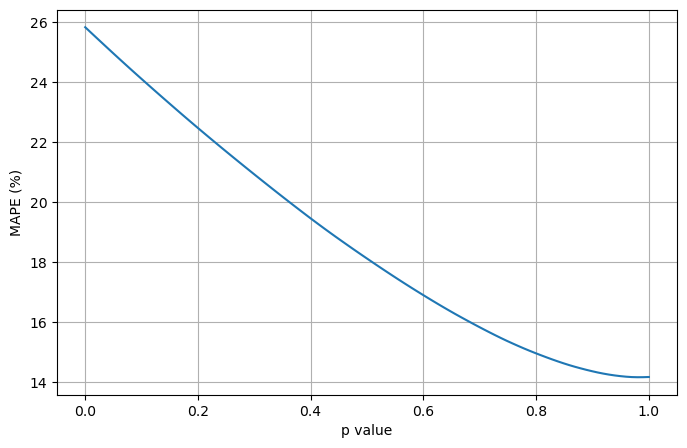

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(p_values, mape_list)

plt.xlabel('p value')
plt.ylabel('MAPE (%)')
# plt.title('MAPE vs Fusion Weight p')

plt.grid(True)
# plt.savefig('Results/knnmape.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
best_idx = np.argmin(mape_list)

best_p = p_values[best_idx]

best_mae  = mae_list[best_idx]
best_rmse = rmse_list[best_idx]
best_mape = mape_list[best_idx]

print(f"Best p (based on MAPE): {best_p:.4f}")
print(f"MAE  : {best_mae:.2f}")
print(f"RMSE : {best_rmse:.2f}")
print(f"MAPE : {best_mape:.2f}%")

Best p (based on MAPE): 0.9798
MAE  : 15.22
RMSE : 35.43
MAPE : 14.16%


In [16]:
# ==============================
# Station-level evaluation (using best_p)
# ==============================

eval_df = test_df.copy()

eval_df['fusion_prediction'] = (
    best_p * eval_df['predictedArrivalDuration'] +
    (1 - best_p) * eval_df['external_pair_mean']
)

eval_df['error'] = (
    eval_df['fusion_prediction'] -
    eval_df['arrivalDuration']
)

adjacent_df = eval_df[
    (eval_df['endStation'] - eval_df['startStation']) == 1
]

station_eval = (
    adjacent_df
    .groupby(['startStation', 'endStation'])
    .agg(
        Samples=('arrivalDuration', 'count'),

        MAE=('error', lambda x: np.mean(np.abs(x))),

        RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),

        MAPE=(
            'arrivalDuration',
            lambda x: np.mean(
                np.abs(
                    (
                        x -
                        adjacent_df.loc[x.index, 'fusion_prediction']
                    )
                    / np.maximum(x, 60)
                )
            ) * 100
        )
    )
    .reset_index()
)

print("\nStation-level evaluation (best_p fusion):")
# print(station_eval.head())

station_eval



Station-level evaluation (best_p fusion):


,startStation,endStation,Samples,MAE,RMSE,MAPE
0,0,1,250,37.604948,96.027467,25.718950
1,1,2,249,14.552373,22.163566,18.445224
2,2,3,258,21.052018,33.945452,22.148039
3,3,4,267,22.577529,37.616697,20.974921
4,4,5,274,14.086813,19.608723,10.073575
5,5,6,265,7.118087,9.495101,11.719983
6,6,7,247,18.359556,29.295417,3.463825
7,7,8,246,9.901834,14.862645,9.353762
8,8,9,262,10.025130,14.245220,14.237021
9,9,10,266,4.534637,6.116957,7.555925


In [17]:
station_eval.to_csv("AP1_station_eval_best_p_knn.csv", index=False)

In [18]:
# ==============================
# Nonlinear Fusion (Squared + sqrt)
# ==============================

fusion_pred_nonlinear = np.sqrt(
    (test_df['predictedArrivalDuration']**2 +
    test_df['external_pair_mean']**2)/2
)

y_true = test_df['arrivalDuration'].values
y_pred = fusion_pred_nonlinear.values

mae_nonlinear = np.mean(np.abs(y_true - y_pred))

rmse_nonlinear = np.sqrt(np.mean((y_true - y_pred) ** 2))

mask = y_true >= 60
mape_nonlinear = np.mean(
    np.abs((y_true[mask] - fusion_pred_nonlinear[mask]) / y_true[mask])
) * 100

print("\nNonlinear Fusion (Squared) Results:")
print(f"MAE  : {mae_nonlinear:.2f}")
print(f"RMSE : {rmse_nonlinear:.2f}")
print(f"MAPE: {mape_nonlinear:.2f}%")


Nonlinear Fusion (Squared) Results:
MAE  : 22.20
RMSE : 44.08
MAPE: 18.59%


In [19]:
# ==============================
# Simple Average Fusion
# ==============================

fusion_pred_avg = (
    test_df['predictedArrivalDuration'] +
    test_df['external_pair_mean']
) / 2

y_true = test_df['arrivalDuration'].values
y_pred = fusion_pred_avg.values

mae_avg = np.mean(np.abs(y_true - y_pred))
rmse_avg = np.sqrt(np.mean((y_true - y_pred) ** 2))

mask = y_true >= 60
mape_avg = np.mean(
    np.abs((y_true[mask] - fusion_pred_avg[mask]) / y_true[mask])
) * 100

print("\nSimple Average Fusion Results:")
print(f"MAE  : {mae_avg:.2f}")
print(f"RMSE : {rmse_avg:.2f}")
print(f"MAPE: {mape_avg:.2f}%")


Simple Average Fusion Results:
MAE  : 21.81
RMSE : 48.06
MAPE: 18.12%


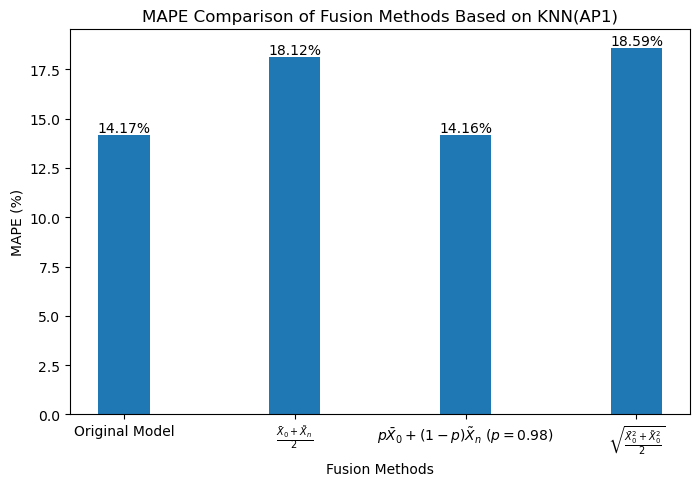

In [20]:
# ==============================
# Bar Chart: Fusion Method Comparison
# ==============================

import matplotlib.pyplot as plt

methods = [
    'Original Model',
    r'$\frac{\bar{X}_0 + \tilde{X}_n}{2}$',
    rf'$p\bar{{X}}_0 + (1-p)\tilde{{X}}_n \ (p={best_p:.2f})$',
    r'$\sqrt{\frac{\bar{X}_0^2+\tilde{X}_0^2}{2}}$'
]
mape_values = [mape, mape_avg, best_mape, mape_nonlinear]

plt.figure(figsize=(8, 5))
plt.bar(methods, mape_values, width=0.3)

plt.ylabel('MAPE (%)')
plt.xlabel('Fusion Methods')
plt.title('MAPE Comparison of Fusion Methods Based on KNN(AP1)')

for i, v in enumerate(mape_values):
    plt.text(i, v, f"{v:.2f}%", ha='center', va='bottom')

plt.grid(False)

plt.savefig('AP1_knn_fusion_method_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()